# Scaper synthetic mixes demo

Browse soundscapes generated by `scripts/generate_soundscapes.py`.

SNR is controlled in **dB** when generating (`--snr-min` / `--snr-max` or `--snr-tier`):

| Tier | dB range |
|------|----------|
| low | 0 – 6 |
| medium | 6 – 15 |
| high | 15 – 30 |

Generate other tiers into separate folders, then point `MANIFEST_PATH` at each manifest to compare.

In [2]:
from pathlib import Path
import csv

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, HTML, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent

# --- edit these ---
MANIFEST_PATH = REPO_ROOT / "data/synthetic/mixes_audioset/manifest_overlay.csv"
MAX_AUDIO_ROWS = 12  # how many mixes to list with players below

In [3]:
def load_manifest(path: Path) -> list[dict]:
    with path.open(newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


def fnum(row: dict, key: str, default: float = 0.0) -> float:
    try:
        return float(row.get(key, default) or default)
    except (TypeError, ValueError):
        return default


rows = load_manifest(MANIFEST_PATH)
if not rows:
    raise FileNotFoundError(
        f"Manifest empty or missing: {MANIFEST_PATH}\n"
        "Run generate_soundscapes.py first (see README)."
    )

snr_means = [fnum(r, "snr_db_mean") for r in rows]
print(f"Manifest: {MANIFEST_PATH}")
print(f"Mixes: {len(rows)}  |  preset: {rows[0].get('preset', '—')}")
if rows[0].get("snr_min_db"):
    print(
        f"SNR range used: {fnum(rows[0], 'snr_min_db'):.1f} – "
        f"{fnum(rows[0], 'snr_max_db'):.1f} dB"
    )
    print(
        f"Per-mix mean SNR: min={min(snr_means):.2f}, "
        f"max={max(snr_means):.2f}, median={float(np.median(snr_means)):.2f} dB"
    )

for r in rows[:8]:
    print(
        f"  mix_{int(r['mix_index']):06d}  "
        f"n={r.get('n_events')}  snr_mean={fnum(r, 'snr_db_mean'):.2f} dB"
    )

Manifest: /home/luusamp/crossroads/voice-anonymization/data/mixes_audioset/manifest_overlay.csv
Mixes: 50  |  preset: overlay
SNR range used: 6.0 – 15.0 dB
Per-mix mean SNR: min=6.52, max=14.76, median=10.45 dB
  mix_000000  n=3  snr_mean=12.05 dB
  mix_000001  n=3  snr_mean=10.48 dB
  mix_000002  n=3  snr_mean=9.76 dB
  mix_000003  n=1  snr_mean=12.44 dB
  mix_000004  n=1  snr_mean=14.37 dB
  mix_000005  n=1  snr_mean=12.57 dB
  mix_000006  n=1  snr_mean=13.36 dB
  mix_000007  n=1  snr_mean=10.05 dB


## Mixes sorted by SNR

Each row shows the **realized** mean foreground SNR (`snr_db_mean`) for that mix. Listen to hear how voice level changes across the batch.

In [4]:
def per_event_snrs(jams_path: Path) -> list[float]:
    try:
        import jams
    except ImportError:
        return []
    jam = jams.load(str(jams_path))
    anns = jam.annotations.search(namespace="scaper")
    if not anns:
        return []
    return [
        float(obs.value["snr"])
        for obs in anns[0].data
        if obs.value.get("role") == "foreground" and "snr" in obs.value
    ]


def load_mono(path: Path, sr: int = 16000) -> tuple[np.ndarray, int]:
    y, _ = librosa.load(path, sr=sr, mono=True)
    return y, sr


snr_rows = sorted(rows, key=lambda r: fnum(r, "snr_db_mean"))[:MAX_AUDIO_ROWS]

print("mix_index | n_events | snr_mean | per-event SNRs (dB)")
print("-" * 55)
for r in snr_rows:
    events = per_event_snrs(Path(r["jams_path"])) if r.get("jams_path") else []
    ev = ", ".join(f"{s:.1f}" for s in events) if events else "—"
    print(
        f"{int(r['mix_index']):9d} | {r.get('n_events', '?'):>8} | "
        f"{fnum(r, 'snr_db_mean'):8.2f} | [{ev}]"
    )

print("\n--- Audio (lowest → highest mean SNR) ---\n")
for r in snr_rows:
    mix_path = Path(r["mix_wav"])
    if not mix_path.is_file():
        print(f"mix_{int(r['mix_index']):06d}: missing {mix_path}")
        continue
    y, sr = load_mono(mix_path)
    events = per_event_snrs(Path(r["jams_path"])) if r.get("jams_path") else []
    event_str = ", ".join(f"{s:.1f}" for s in events) if events else "—"
    label = (
        f"mix_{int(r['mix_index']):06d}  |  "
        f"mean SNR {fnum(r, 'snr_db_mean'):.1f} dB  |  "
        f"events [{event_str}] dB"
    )
    display(HTML(f"<b>{label}</b>"))
    display(Audio(y, rate=sr))

mix_index | n_events | snr_mean | per-event SNRs (dB)
-------------------------------------------------------
       29 |        1 |     6.52 | [6.5]
       45 |        1 |     6.67 | [6.7]
       46 |        1 |     6.73 | [6.7]
        8 |        2 |     8.00 | [8.7, 7.3]
       41 |        3 |     8.16 | [8.5, 7.0, 9.0]
       24 |        3 |     8.20 | [6.4, 9.9, 8.2]
       44 |        3 |     8.55 | [6.3, 7.4, 11.9]
       38 |        3 |     8.58 | [7.3, 10.1, 8.4]
       27 |        2 |     8.59 | [6.5, 10.7]
       11 |        3 |     8.80 | [13.2, 7.0, 6.2]
       19 |        3 |     9.02 | [9.0, 8.6, 9.5]
       28 |        1 |     9.33 | [9.3]

--- Audio (lowest → highest mean SNR) ---



## Inspect one mix

Set `MIX_INDEX` to any row from the manifest.

Mix: mix_000000.wav
Background: urban
Events: 3  |  duration: 10.0s
SNR: 12.05 dB mean (range 6.0–15.0)


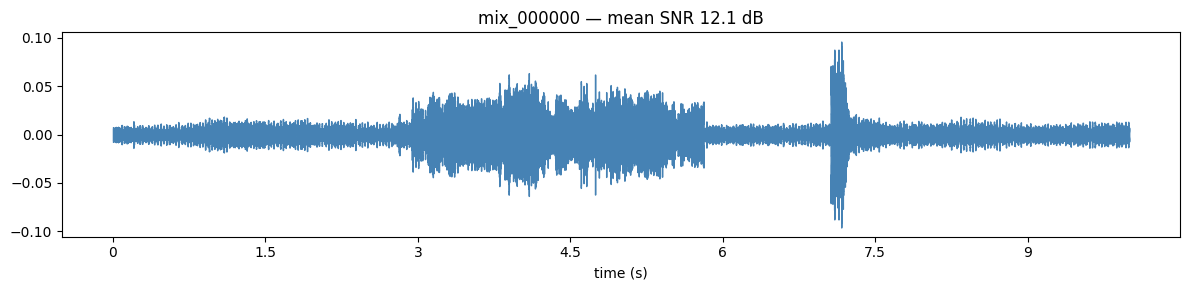

In [5]:
MIX_INDEX = 0

row = next((r for r in rows if int(r["mix_index"]) == MIX_INDEX), None)
if row is None:
    raise IndexError(f"mix_index {MIX_INDEX} not in manifest")

mix_path = Path(row["mix_wav"])
y, sr = load_mono(mix_path)

print(f"Mix: {mix_path.name}")
print(f"Background: {row.get('background_label', '—')}")
print(f"Events: {row.get('n_events')}  |  duration: {fnum(row, 'duration_sec'):.1f}s")
print(
    f"SNR: {fnum(row, 'snr_db_mean'):.2f} dB mean "
    f"(range {fnum(row, 'snr_min_db'):.1f}–{fnum(row, 'snr_max_db'):.1f})"
)

fig, ax = plt.subplots(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr, ax=ax, color="steelblue")
ax.set_title(f"mix_{MIX_INDEX:06d} — mean SNR {fnum(row, 'snr_db_mean'):.1f} dB")
ax.set_xlabel("time (s)")
fig.tight_layout()
plt.show()

display(Audio(y, rate=sr))

## Compare SNR tiers (optional)

After generating separate batches, list manifests here:

In [6]:
TIER_MANIFESTS = {
    "low": REPO_ROOT / "data/synthetic/mixes_audioset_low/manifest_eval_low.csv",
    "medium": REPO_ROOT / "data/synthetic/mixes_audioset/manifest_overlay.csv",
    "high": REPO_ROOT / "data/synthetic/mixes_audioset_high/manifest_eval_high.csv",
}

tier_rows = []
for tier, path in TIER_MANIFESTS.items():
    if not path.is_file():
        continue
    trows = load_manifest(path)
    means = [fnum(r, "snr_db_mean") for r in trows]
    tier_rows.append({
        "tier": tier,
        "n_mixes": len(trows),
        "snr_min_db": fnum(trows[0], "snr_min_db") if trows else None,
        "snr_max_db": fnum(trows[0], "snr_max_db") if trows else None,
        "mean_snr_median": float(np.median(means)) if means else None,
        "example_mix": trows[0]["mix_wav"] if trows else None,
    })

if not tier_rows:
    print("No tier manifests found yet. Example commands:")
    print("  generate_soundscapes.py --preset eval --snr-tier low  --out-dir data/synthetic/mixes_audioset_low")
    print("  generate_soundscapes.py --preset eval --snr-tier high --out-dir data/synthetic/mixes_audioset_high")
else:
    print(f"{'tier':<8} {'n':>4}  {'snr range':>14}  median mean SNR")
    for t in tier_rows:
        print(
            f"{t['tier']:<8} {t['n_mixes']:4d}  "
            f"{t['snr_min_db']:.0f}–{t['snr_max_db']:.0f} dB      "
            f"{t['mean_snr_median']:.2f} dB"
        )
    print("\n--- One example per tier ---\n")
    for t in tier_rows:
        path = Path(t["example_mix"])
        if not path.is_file():
            continue
        y, sr = load_mono(path)
        display(HTML(
            f"<b>{t['tier']} tier ({t['snr_min_db']:.0f}–{t['snr_max_db']:.0f} dB)</b>"
        ))
        display(Audio(y, rate=sr))

tier        n       snr range  median mean SNR
medium     50  6–15 dB      10.45 dB

--- One example per tier ---

